# 1

In [26]:
import pandas as pd
import numpy as np

data = pd.read_csv("./exam_2021_02_17_data.csv", sep="\t")
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns")
for c in data.columns:
    frquencies = np.unique(data[c], return_counts=True)
    print(f"For the attribute {c}:")
    for v,occ in zip(frquencies[0], frquencies[1]):
        print(f"\t{v} has frequency of {occ/len(data[c])}%")

There are 1000 rows and 3 columns
For the attribute F0:
	a has frequency of 0.1%
	b has frequency of 0.1%
	c has frequency of 0.1%
	d has frequency of 0.1%
	e has frequency of 0.1%
	f has frequency of 0.1%
	g has frequency of 0.1%
	h has frequency of 0.1%
	i has frequency of 0.1%
	j has frequency of 0.1%
For the attribute F1:
	a has frequency of 0.1%
	b has frequency of 0.099%
	c has frequency of 0.1%
	d has frequency of 0.1%
	e has frequency of 0.101%
	f has frequency of 0.1%
	g has frequency of 0.1%
	h has frequency of 0.1%
	i has frequency of 0.1%
	j has frequency of 0.1%
For the attribute F2:
	a has frequency of 0.1%
	b has frequency of 0.099%
	c has frequency of 0.1%
	d has frequency of 0.1%
	e has frequency of 0.101%
	f has frequency of 0.1%
	g has frequency of 0.1%
	h has frequency of 0.1%
	i has frequency of 0.1%
	j has frequency of 0.1%


# 2

In [27]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(feature_name_combiner="concat")
df = pd.DataFrame(
    data = encoder.fit_transform(data).toarray(),
    columns = encoder.get_feature_names_out(),
    dtype=np.int32
)
df

,F0_a,F0_b,F0_c,F0_d,F0_e,F0_f,F0_g,F0_h,F0_i,F0_j,...,F2_a,F2_b,F2_c,F2_d,F2_e,F2_f,F2_g,F2_h,F2_i,F2_j
0,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
996,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
997,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
998,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


# 3

In [28]:
def size_deviation_index(y,n_clusters):
    return np.sqrt(np.unique(y,return_counts=True)[1].var()) / n_clusters

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

random_state = 42
ks = [*range(2,11)]
silhouette_list = []
inertia_list = []
size_deviation_list = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=random_state)
    y_km = model.fit_predict(df)
    silhouette_list.append(silhouette_score(df, y_km))
    inertia_list.append(model.inertia_)
    size_deviation_list.append(size_deviation_index(y_km,k))

# 4

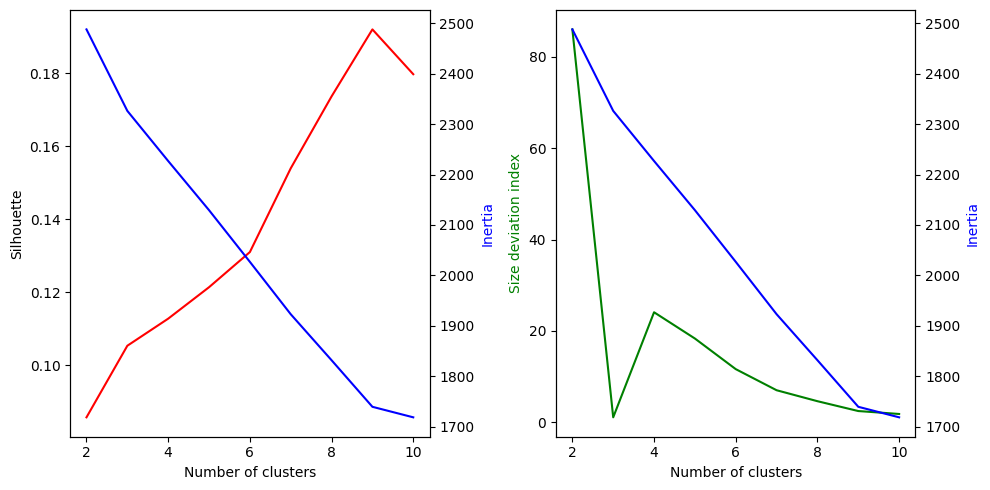

In [ ]:
import matplotlib.pyplot as plt
fig, (ax1,ax3) = plt.subplots(1,2, figsize=[10,5])

color="r"
ax1.plot(ks, silhouette_list, c=color)
ax1.set_xlabel("Number of clusters")
ax1.set_ylabel("Silhouette")

color="b"
ax2 = ax1.twinx()
ax2.plot(ks, inertia_list, c=color)
ax2.set_ylabel("Inertia", c=color)

color="g"
ax3.plot(ks, size_deviation_list, c=color)
ax3.set_xlabel("Number of clusters")
ax3.set_ylabel("Size deviation index", c=color)

color="b"
ax4 = ax3.twinx()
ax4.plot(ks, inertia_list, c=color)
ax4.set_ylabel("Inertia", c=color)

plt.tight_layout()
plt.show()

As said in the text, the elbow method is not very meaningful as the inertia is quite linearly decreasing and the silhouette is too low.

Looking at the other plot, we can see that the size deviation index (which we want to minimize) has an important decrease in $K=3$ and then immediately after increase and we can find a value as small as this one only  with a much higher number of clusters.

We'll then choose $K=3$

In [39]:
K = 3
best_km = KMeans(K, random_state=random_state)
y_km_best = best_km.fit_predict(df)

# 5

In [41]:
from sklearn.cluster import AgglomerativeClustering

ac = AgglomerativeClustering(n_clusters=K)
y_ac = ac.fit_predict(df)

# 6

0.7223526572023274

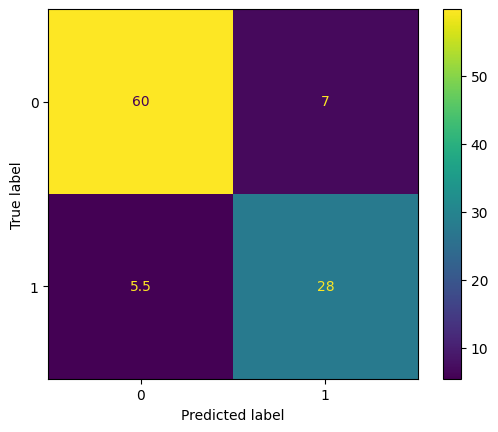

In [53]:
from sklearn.metrics.cluster import pair_confusion_matrix
from sklearn.metrics import adjusted_rand_score, ConfusionMatrixDisplay

normalize_pcm = pair_confusion_matrix(y_km_best, y_ac)
ConfusionMatrixDisplay(
    normalize_pcm / np.sum(normalize_pcm) * 100
).plot();

adjusted_rand_score(y_km_best, y_ac)

By comparing the result we can observe that
- The djusted random score: 72% which is medium-high as the value which means that the 2 clusters are similar
- The confusion matrix shows that the label are clustered in the same way in the 88% of the cases so a very important clue of similarity